# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## AT LAST - it's time for Fine Tuning!

After all this data preparation, and old school machine learning, we've finally arrived at the moment you've been waiting for. Fine-tuning a model.

In [1]:
# imports

import os
import re
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
from openai import OpenAI
from anthropic import Anthropic

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HUGGING_FACE_TOKEN', 'your-key-if-not-using-env')

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from items import Item
from testing import Tester

In [5]:
openai = OpenAI()

In [6]:
%matplotlib inline

In [7]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [8]:
# OpenAI recommends fine-tuning with populations of 50-100 examples
# But as our examples are very small, I'm suggesting we go with 200 examples (and 1 epoch)

fine_tune_train = train[:200]
fine_tune_validation = train[200:250]

# Step 1

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI

In [9]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [10]:
messages_for(train[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': "How much does this cost?\n\nAqua79 Clear Seahorse Keychain - Silver 3D Sparkling Charm Rhinestones Fashionable Stylish Metal Alloy Durable Keyring Bling Crystal Jewelry Accessory With Clasp For Keychain, Purse, Backpack, Handbag\nTHE CLEAR SEAHORSE SPARKLING CHARM KEYCHAIN COMES WITH UNIQUE EDGY DESIGN YOU WILL LOVE - This high quality, rich & beautiful unique charm accessory will make sure everyone's eyes are on you, giving you the added fashionable edge & appeal. At the same time the seahorse keychain is useful and functional, it can fit many keys in all styles & shapes, and the clasp can be used to secure & bling to any bag, purse or similar. Just clip it on and make a beautiful fashion"},
 {'role': 'assistant', 'content': 'Price is $10.99'}]

In [11]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...


def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [12]:
print(make_jsonl(train[:3]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\nAqua79 Clear Seahorse Keychain - Silver 3D Sparkling Charm Rhinestones Fashionable Stylish Metal Alloy Durable Keyring Bling Crystal Jewelry Accessory With Clasp For Keychain, Purse, Backpack, Handbag\nTHE CLEAR SEAHORSE SPARKLING CHARM KEYCHAIN COMES WITH UNIQUE EDGY DESIGN YOU WILL LOVE - This high quality, rich & beautiful unique charm accessory will make sure everyone's eyes are on you, giving you the added fashionable edge & appeal. At the same time the seahorse keychain is useful and functional, it can fit many keys in all styles & shapes, and the clasp can be used to secure & bling to any bag, purse or similar. Just clip it on and make a beautiful fashion"}, {"role": "assistant", "content": "Price is $10.99"}]}
{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the 

In [13]:
# Convert the items into jsonl and write them to a file

def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [14]:
write_jsonl(fine_tune_train, "fine_tune_train.jsonl")

In [15]:
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

In [16]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [17]:
train_file

FileObject(id='file-Ae9njcYbpeFUE8REwC7yWF', bytes=182578, created_at=1747786620, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [18]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [19]:
validation_file

FileObject(id='file-4H1GiKfQ32ZTNyvs9f2Mv5', bytes=44566, created_at=1747786633, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

# Step 2

I love Weights and Biases - a beautiful, free platform for monitoring training runs.  
Weights and Biases is integrated with OpenAI for fine-tuning.

First set up your weights & biases free account at:

https://wandb.ai

From the Avatar >> Settings menu, near the bottom, you can create an API key.

Then visit the OpenAI dashboard at:

https://platform.openai.com/account/organization

In the integrations section, you can add your Weights & Biases key.

## And now time to Fine-tune!

In [20]:
wandb_integration = {"type": "wandb", "wandb": {"project": "gpt-pricer"}}

In [21]:
train_file.id

'file-Ae9njcYbpeFUE8REwC7yWF'

In [22]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4o-mini-2024-07-18",
    seed=42,
    hyperparameters={"n_epochs": 1},
    integrations = [wandb_integration],
    suffix="pricer"
)

FineTuningJob(id='ftjob-9l2bEe5LhKOxsNUWWhYwla2M', created_at=1747787397, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-fTJfwsi8e2KHtpWLDOCdoUPy', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-Ae9njcYbpeFUE8REwC7yWF', validation_file='file-4H1GiKfQ32ZTNyvs9f2Mv5', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-9l2bEe5LhKOxsNUWWhYwla2M'))], metadata=None, method=Method(dpo=None, supervised=MethodSupervised(hyperparameters=MethodSupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1)), type='supervised'), user_provided_suffix='pricer', usage_metr

In [23]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-9l2bEe5LhKOxsNUWWhYwla2M', created_at=1747787397, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-fTJfwsi8e2KHtpWLDOCdoUPy', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-Ae9njcYbpeFUE8REwC7yWF', validation_file='file-4H1GiKfQ32ZTNyvs9f2Mv5', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-9l2bEe5LhKOxsNUWWhYwla2M'))], metadata=None, method=Method(dpo=None, supervised=MethodSupervised(hyperparameters=MethodSupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1)), type='supervised'), user_

In [24]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [25]:
job_id

'ftjob-9l2bEe5LhKOxsNUWWhYwla2M'

In [26]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-9l2bEe5LhKOxsNUWWhYwla2M', created_at=1747787397, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-fTJfwsi8e2KHtpWLDOCdoUPy', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-Ae9njcYbpeFUE8REwC7yWF', validation_file='file-4H1GiKfQ32ZTNyvs9f2Mv5', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-9l2bEe5LhKOxsNUWWhYwla2M'))], metadata=None, method=Method(dpo=None, supervised=MethodSupervised(hyperparameters=MethodSupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1)), type='supervised'), user_provided_suffix='pricer', usage_metr

In [36]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-SHhFyywSPpQ7nNIhgWqH1arW', created_at=1747788783, level='info', message='The job has successfully completed', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-MkW2JAH5h3rJi2CEB43LdypI', created_at=1747788778, level='info', message='Usage policy evaluations completed, model is now enabled for sampling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-jNJ7JqVBved4v3zIfOB3MEzl', created_at=1747787956, level='info', message='Evaluating model against our usage policies before enabling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-pW8SZ5lzLrli0VNk2oKeZLzt', created_at=1747787956, level='info', message='New fine-tuned model created', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-532NLgN6FpzVtlnviuDxKDZl', created_at=1747787913, level='info', message='Step 200/200: training loss=1.22, validat

# Step 3

Test our fine tuned model

In [37]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [38]:
fine_tuned_model_name

'ft:gpt-4o-mini-2024-07-18:personal:pricer:BZRmG8S9'

In [39]:
# The prompt

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [40]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nArch Memory 4GB DDR3L 1866 MHz So-dimm RAM for Synology NAS Systems DiskStation DS718+\nCompatible with Synology 4GB 204 Pin Sodimm 1.35 volts; Single Rank (1Rx8) Access crucial data faster by upgrading your internal memory Rugged tier one ic chipsets; built for performance and security RAM 4 GB DDR3, Brand Arch Memory, model number Weight 2.08 ounces, Dimensions 2.13 x 0.06 x 1.19 inches, Dimensions LxWxH 2.13 x 0.06 x 1.19 inches, Voltage 1.35 Volts, Manufacturer Arch Memory,'},
 {'role': 'assistant', 'content': 'Price is $'}]

In [41]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [42]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [43]:
# The function for gpt-4o-mini

def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name, 
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [44]:
print(test[0].price)
print(gpt_fine_tuned(test[0]))

28.95
52.74


In [45]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

Arch Memory 4GB DDR3L 1866 MHz So-dimm RAM for Synology NAS Systems DiskStation DS718+
Compatible with Synology 4GB 204 Pin Sodimm 1.35 volts; Single Rank (1Rx8) Access crucial data faster by upgrading your internal memory Rugged tier one ic chipsets; built for performance and security RAM 4 GB DDR3, Brand Arch Memory, model number Weight 2.08 ounces, Dimensions 2.13 x 0.06 x 1.19 inches, Dimensions LxWxH 2.13 x 0.06 x 1.19 inches, Voltage 1.35 Volts, Manufacturer Arch Memory,

Price is $


1: Guess: $52.74 Truth: $28.95 Error: $23.79 SLE: 0.34 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $21.32 Truth: $25.99 Error: $4.67 SLE: 0.04 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $99.99 Truth: $260.00 Error: $160.01 SLE: 0.90 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $594.65 Truth: $419.99 Error: $174.66 SLE: 0.12 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $118.99 Truth: $279.99 Error: $161.00 SLE: 0.72 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $156.66 Truth: $62.02 Error: $94.64 SLE: 0.84 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $219.00 Truth: $190.49 Error: $28.51 SLE: 0.02 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $83.99 Truth: $120.99 Error: $37.00 SLE: 0.13 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $103.32 Truth: $153.67 Error: $50.35 SLE: 0.16 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $196.99 Truth: $91.99 Error: $1

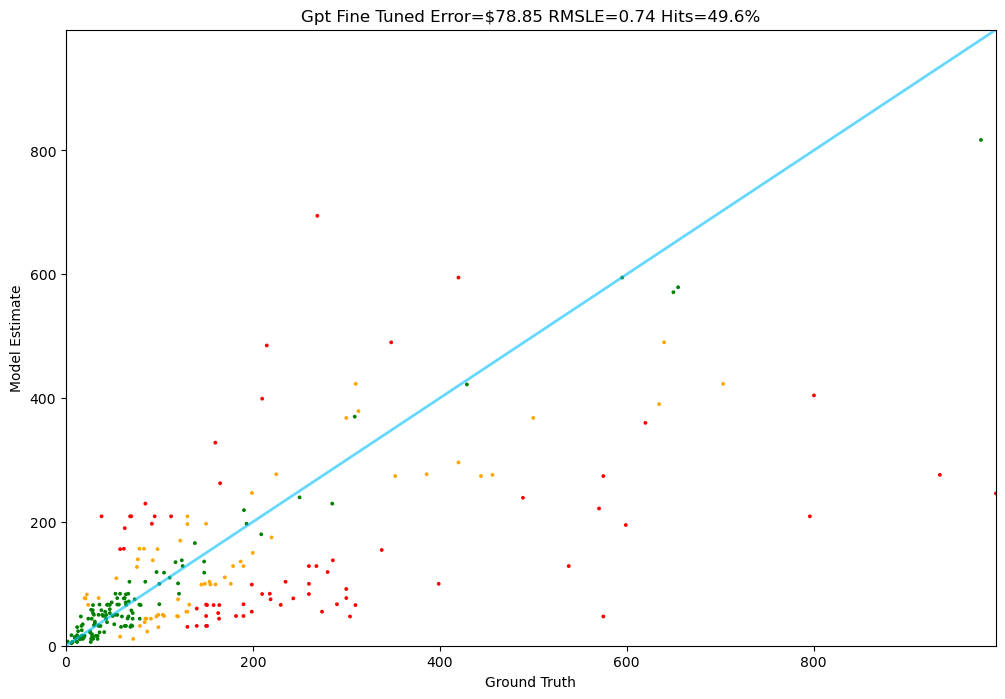

In [46]:
Tester.test(gpt_fine_tuned, test)